<a href="https://colab.research.google.com/github/vaibhavkatex/The-Internship-2026/blob/main/Session_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Q1. Load the Heart Disease dataset using pandas and display the first 10 rows.
Also check the shape and basic information (info()) of the dataset.***

In [54]:
import numpy as np
import pandas as pd
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# uploading a Dataset
from google.colab import files
Uploaded = files.upload()

Saving heart.csv to heart.csv


In [27]:
df = pd.read_csv("heart.csv")
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [26]:
print("Shape :",df.shape)
print("Basic Information :",df.info())

Shape : (918, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
Basic Information : None


**Q2. Check for missing values in the dataset. Show the count of null values for
each column.**

In [37]:
# Check missing values in each column
print(df.isnull().sum())


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


**Q3. Check for duplicate rows in the dataset. If any duplicates are found, remove
them and print the new shape of the dataset.**

In [41]:
# Check duplicate rows
duplicate_rows = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_rows)

# Remove duplicate rows (if any)
df = df.drop_duplicates()

# Print new shape of dataset
print("New Shape of Dataset:", df.shape)

Number of Duplicate Rows: 0
New Shape of Dataset: (918, 12)


**Q4. Identify unrealistic/invalid values:
Count how many rows have Cholesterol = 0.
Count how many rows have RestingBP = 0.
Print both counts.**

In [43]:
# Count rows where Cholesterol = 0
cholesterol_zero = (df['Cholesterol'] == 0).sum()

# Count rows where RestingBP = 0
restingbp_zero = (df['RestingBP'] == 0).sum()

# Print the counts
print("Rows with Cholesterol = 0:", cholesterol_zero)
print("Rows with RestingBP = 0:", restingbp_zero)

Rows with Cholesterol = 0: 172
Rows with RestingBP = 0: 1


**Q5. Clean the invalid values:
Replace Cholesterol = 0 with the mean cholesterol value (excluding zeros).
Replace RestingBP = 0 with the mean resting blood pressure value (excluding
zeros).
Round both columns to 2 decimal places.
Print the statistical summary (describe()) of these two columns before and after
cleaning.**

In [52]:
# Display summary before cleaning
print("Before Cleaning")
print(df[['Cholesterol', 'RestingBP']].describe())

# Calculate mean excluding zero values
chol_mean = df[df['Cholesterol'] != 0]['Cholesterol'].mean()
bp_mean = df[df['RestingBP'] != 0]['RestingBP'].mean()

# Replace 0 values with the calculated mean
df['Cholesterol'] = df['Cholesterol'].replace(0, chol_mean)
df['RestingBP'] = df['RestingBP'].replace(0, bp_mean)

# Round both columns to 2 decimal places
df['Cholesterol'] = df['Cholesterol'].round(2)
df['RestingBP'] = df['RestingBP'].round(2)

# Display summary after cleaning
print("\nAfter Cleaning")
print(df[['Cholesterol', 'RestingBP']].describe())

Before Cleaning
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

After Cleaning
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


**Q6. Create a function to plot histograms for the following numerical columns:
Age
RestingBP
Cholesterol
MaxHR
Plot all four histograms in one figure using subplots (2x2 layout). Use this function
to visualize the data after cleaning.**

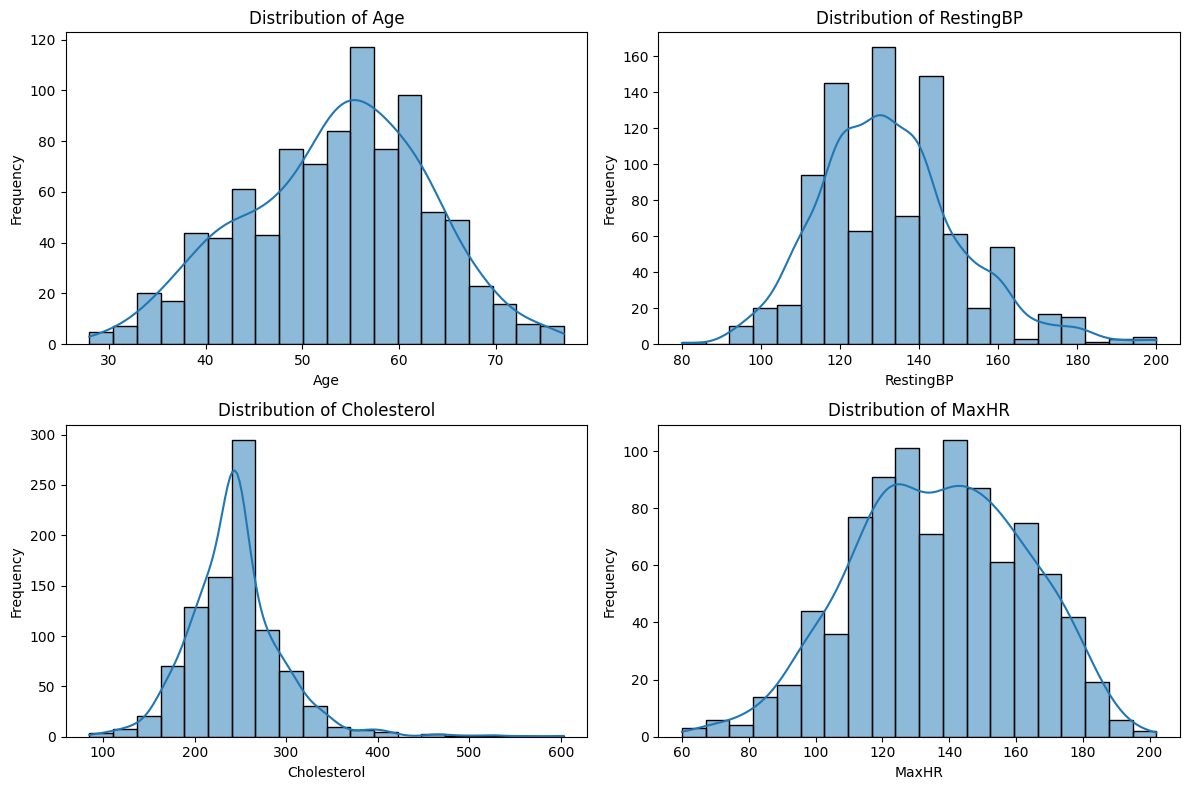

In [56]:


# Function to plot histograms
def plot_histograms(data):

    columns = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']

    plt.figure(figsize=(12, 8))

    for i, col in enumerate(columns, 1):
        plt.subplot(2, 2, i)
        sns.histplot(data[col], kde=True, bins=20)

        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

# Call the function after cleaning
plot_histograms(df)

**Q7. Identify and print numerical columns and categorical columns separately.**

In [57]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Print the columns
print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

Categorical Columns:
Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


**Q8. Perform One-Hot Encoding on all categorical columns using
pd.get_dummies().
Store the result in a new dataframe called df_encoded.
Print the shape and the first 5 rows of the encoded dataframe.**

In [58]:

# Perform One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Print shape of encoded dataframe
print("Shape of Encoded DataFrame:", df_encoded.shape)

# Print first 5 rows
print("\nFirst 5 Rows of Encoded DataFrame:")
print(df_encoded.head())

Shape of Encoded DataFrame: (918, 16)

First 5 Rows of Encoded DataFrame:
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_M  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
0   True               True              False             False   
1  False              False               True             False   
2   True               True              False             False   
3  False              False              False             False   
4   True              False               True             False   

   RestingECG_Normal  RestingECG_ST  ExerciseAngina_Y  ST_Slope_Fl

**Q9. After cleaning and encoding:
Print the final shape of df_encoded.
Show the list of all column names in the final dataframe.**

In [59]:
# Print the final shape of the encoded dataframe
print("Final Shape of df_encoded:", df_encoded.shape)

# Print all column names
print("\nColumn Names:")
print(df_encoded.columns)

Final Shape of df_encoded: (918, 16)

Column Names:
Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')


**Q10. (Summary)
Write a short summary (in comments or markdown) covering:
1. What invalid values did you find and how did you fix them?
2. Why is it important to handle invalid values like Cholesterol = 0?
3. What is the purpose of One-Hot Encoding?
4. Any other observations from the cleaning process.**

In [60]:
# ===================== Summary =====================

# 1. Invalid Values Found and Fixed:
#    - The dataset contained invalid values where Cholesterol = 0
#      and RestingBP = 0.
#    - These values were replaced with the mean of the respective
#      columns after excluding the zero values.
#    - Finally, both columns were rounded to 2 decimal places.

# 2. Importance of Handling Invalid Values:
#    - A Cholesterol or RestingBP value of 0 is not realistic for
#      a living person.
#    - Such invalid values can reduce the accuracy of data analysis
#      and machine learning models.
#    - Replacing them with the mean helps maintain a more reliable dataset.

# 3. Purpose of One-Hot Encoding:
#    - One-Hot Encoding converts categorical variables into numerical
#      columns (0 and 1).
#    - Machine Learning algorithms work with numerical data, so
#      encoding is necessary before model training.

# 4. Other Observations:
#    - The dataset became cleaner after replacing invalid values.
#    - All categorical columns were successfully converted into
#      numerical format.
#    - The encoded dataset is now ready for further analysis and
#      machine learning.